# Changing Bases Using Eulerian Transforms

This section demonstrates the Eulerian change-of-basis formulation. The core idea is that we can define a continuous isometry (an orthogonal transformation) $Q(t)$ in function space governed by the following ordinary differential equation (ODE):

$$\dot{Q}(t) = K(t) Q(t), \qquad Q(0) = I$$

Here, $K(t)$ is a skew-symmetric operator that acts as the generator of the isometry:

$$K(t) = 2 \left[ v_\theta(t, \cdot) \otimes \dot{v}_\theta(t, \cdot) - \dot{v}_\theta(t, \cdot) \otimes v_\theta(t, \cdot) \right]$$

where $v_\theta(t, x)$ is a parameterized spatiotemporal neural field. 

Applying this transformation to a function $f$ defines a pushforward operator, $f(t) = Q(t) f(0)$. Taking the time derivative of this function yields its transport equation:

$$\dot{f}(t) = \dot{Q}(t) f(0) = K(t) f(t)$$

As detailed in the accompanying paper, this continuous ODE can be approximated to the first order using a discrete sequence of Householder reflections. 

Let $H_i$ be the Householder reflection operator defined along the vector field $v_\theta$ at time step $t_i$:

$$H_i = I - 2 \frac{v_\theta(t_i, \cdot) \otimes v_\theta(t_i, \cdot)}{\langle v_\theta(t_i, \cdot) , v_\theta(t_i, \cdot) \rangle}$$

Because the product of two reflections forms a rotation, we can approximate the temporal evolution of $f$ up to time $t_K$ by compounding pairs of reflections:

$$f(t_K) \approx (H_{K-1} H_{K}) (H_{K-2} H_{K-1}) \cdots (H_1 H_2) (H_0 H_1) f(0)$$


In practice, we do not construct the full, dense outer-product matrices. Instead, the action of a Householder matrix on a function $f$ is computed directly. By discretizing the spatial domain onto a grid, we can approximate the inner products $\langle \cdot, \cdot \rangle$ using Monte Carlo integration:

$$H_i f = f - 2 \frac{\langle v_\theta(t_i, \cdot), f \rangle}{\langle v_\theta(t_i, \cdot), v_\theta(t_i, \cdot) \rangle} v_\theta(t_i, \cdot)$$

Consequently, applying these isometries simply requires starting with function values on a grid and iteratively applying the Householder product sequence. The operation purely transforms the function values and does not alter the underlying spatial grid coordinates, provided the grid contains enough points for accurate Monte Carlo evaluation.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Run the following code to create such an isometry:

In [4]:
%autoreload 2 
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.networks import FourierDistortedFieldV2, FourierDistortedFieldV3
import functools

# manual seed for reproducibility
torch.manual_seed(0)
# isometry = EulerianIsometry(
#     coords_dim=2,
#     channels_dim=1,
#     gradient_checkpointing=True,
#     acceleration=10.0,
#     scalar_field_partial=functools.partial(
#         FourierDistortedFieldV2,
#         n_modes=4,
#         freq_strides=1,
#         time_hidden_dims=[256, 256],
#         n_time_freqs=256,
#         low_freq=0.0,
#         high_freq=5.0,
#         low_t=0.0,
#         high_t=1.0,
#         gamma=1.0,
#         activation=torch.nn.SiLU,
#     ),
# ).to(device)

isometry = EulerianIsometry(
    coords_dim=2,
    channels_dim=1,
    gradient_checkpointing=True,
    acceleration=30.0,
    scalar_field_partial=functools.partial(
        FourierDistortedFieldV3,
        n_truncation=3,
        spatial_hidden_dims=[256, 256, 256],
        # time_hidden_dims=[256, 256],
        n_time_freqs=256,
        low_t=0.0,
        high_t=1.0,
        activation=torch.nn.SiLU,
    ),
).to(device)

Next, run the transformation on a fixed grid and solve the ODE:

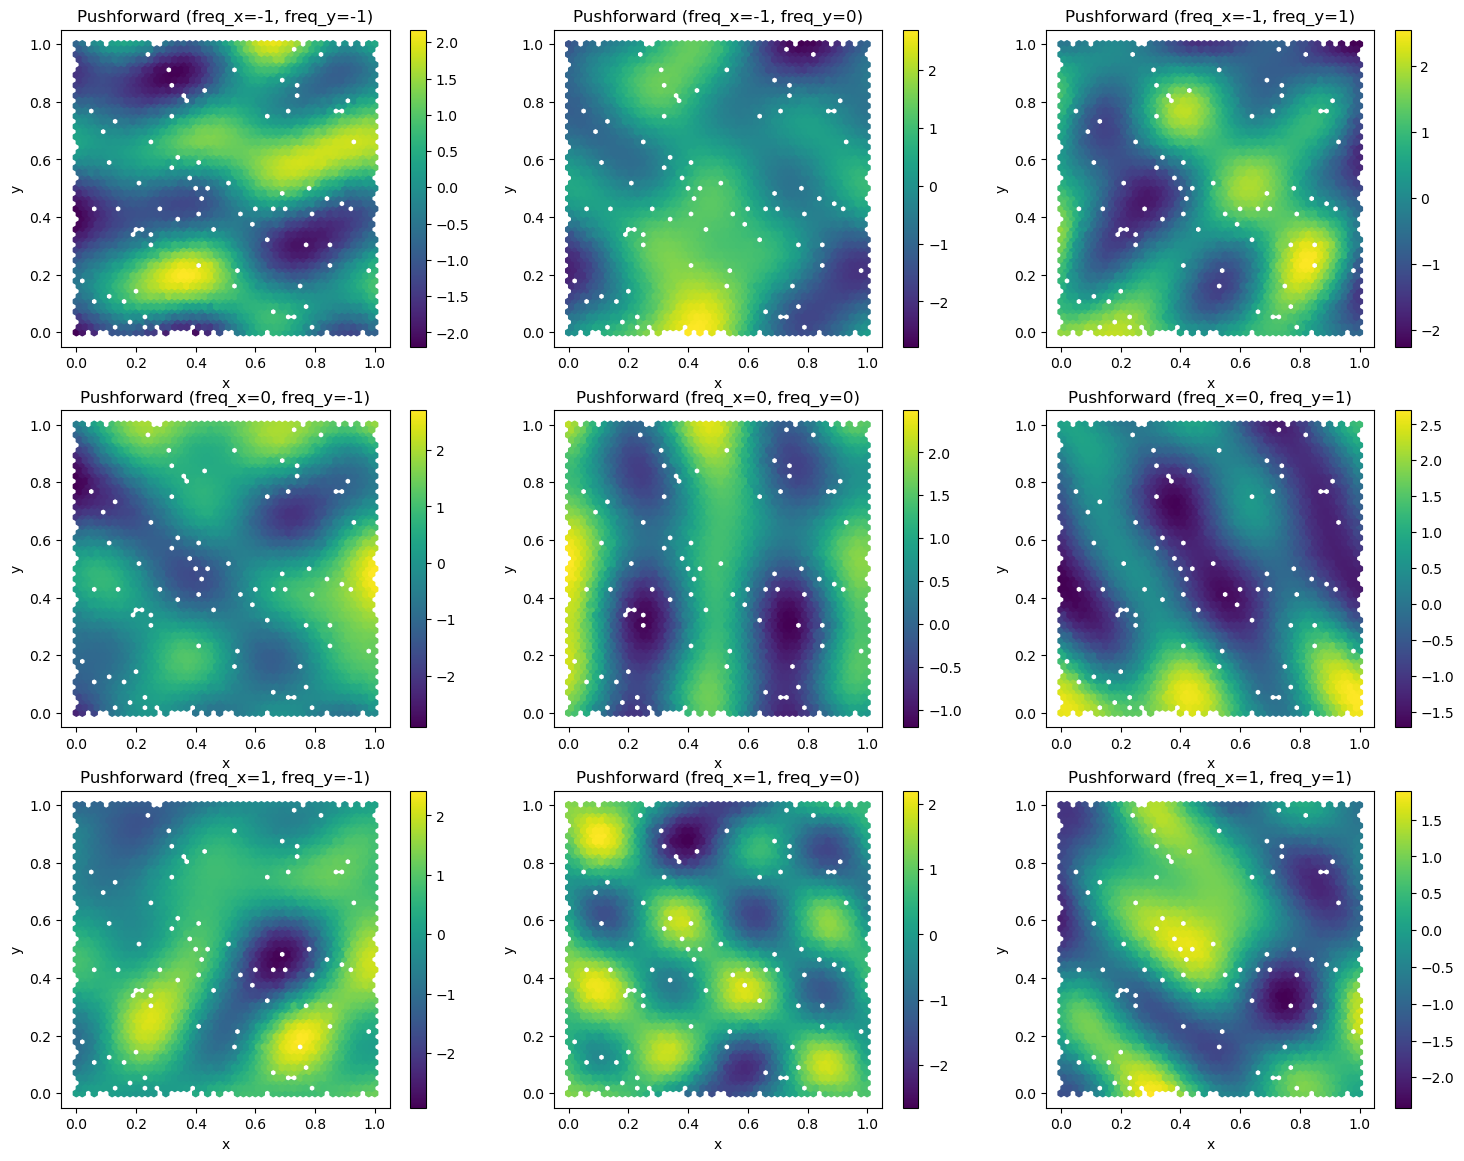

In [5]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

fourier_basis = FourierDictionary(
    domain_dim=2,
    num_channels=1,
    p=0.1,
)
indices_tensorized = fourier_basis.get_truncated_indices(2).to(device)

# seed everything for reproducibility
torch.manual_seed(0)
N_per_dim = 100
end_time = 1.0
all_deformed_vals = []
xy = SquareSampler().sample(N_per_dim).to(device)
src_field = fourier_basis.get_atoms(xy, indices_tensorized)
isometry.shuffle_model_state(100)
tgt_coords, _, tgt_field = isometry.pushforward(
    xy,
    torch.zeros(xy.shape[0], device=xy.device),
    src_field,
    start_time=0.0,
    end_time=end_time,
)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        # approximate integral by monte carlo
        ax.hexbin(
            tgt_coords[:,0].detach().cpu(), 
            tgt_coords[:,1].detach().cpu(), 
            C=tgt_field[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        idx_x = indices_tensorized[row * 3 + col, 0].item()
        idx_y = indices_tensorized[row * 3 + col, 1].item()
        ax.set_title(f'Pushforward (freq_x={idx_x}, freq_y={idx_y})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


Next, run pairwise inner products before and after the transformation; you should expect to see the same heatmaps as the transformation is by design an isometry:

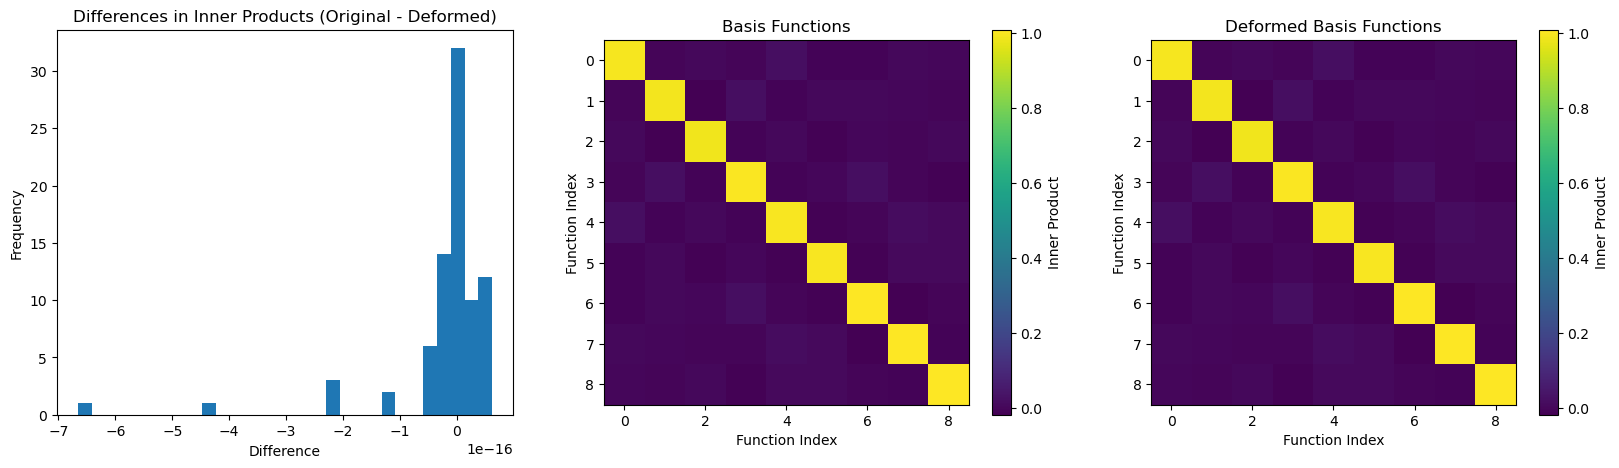

In [6]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product

# compute pairwise inner products
N = N_per_dim ** 2
inner_products = pairwise_inner_product(src_field, src_field)
inner_products_deformed = pairwise_inner_product(tgt_field, tgt_field)
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


## Visualizing the Generator Fields $\alpha_\theta$ and $\beta_\theta$

The skew-adjoint generator $K_\theta(t)$ is defined by two scalar fields $\alpha_\theta(t, \cdot)$ and $\beta_\theta(t, \cdot)$. Below we evaluate and plot both fields on the unit square at several timesteps from $0$ to $1$.

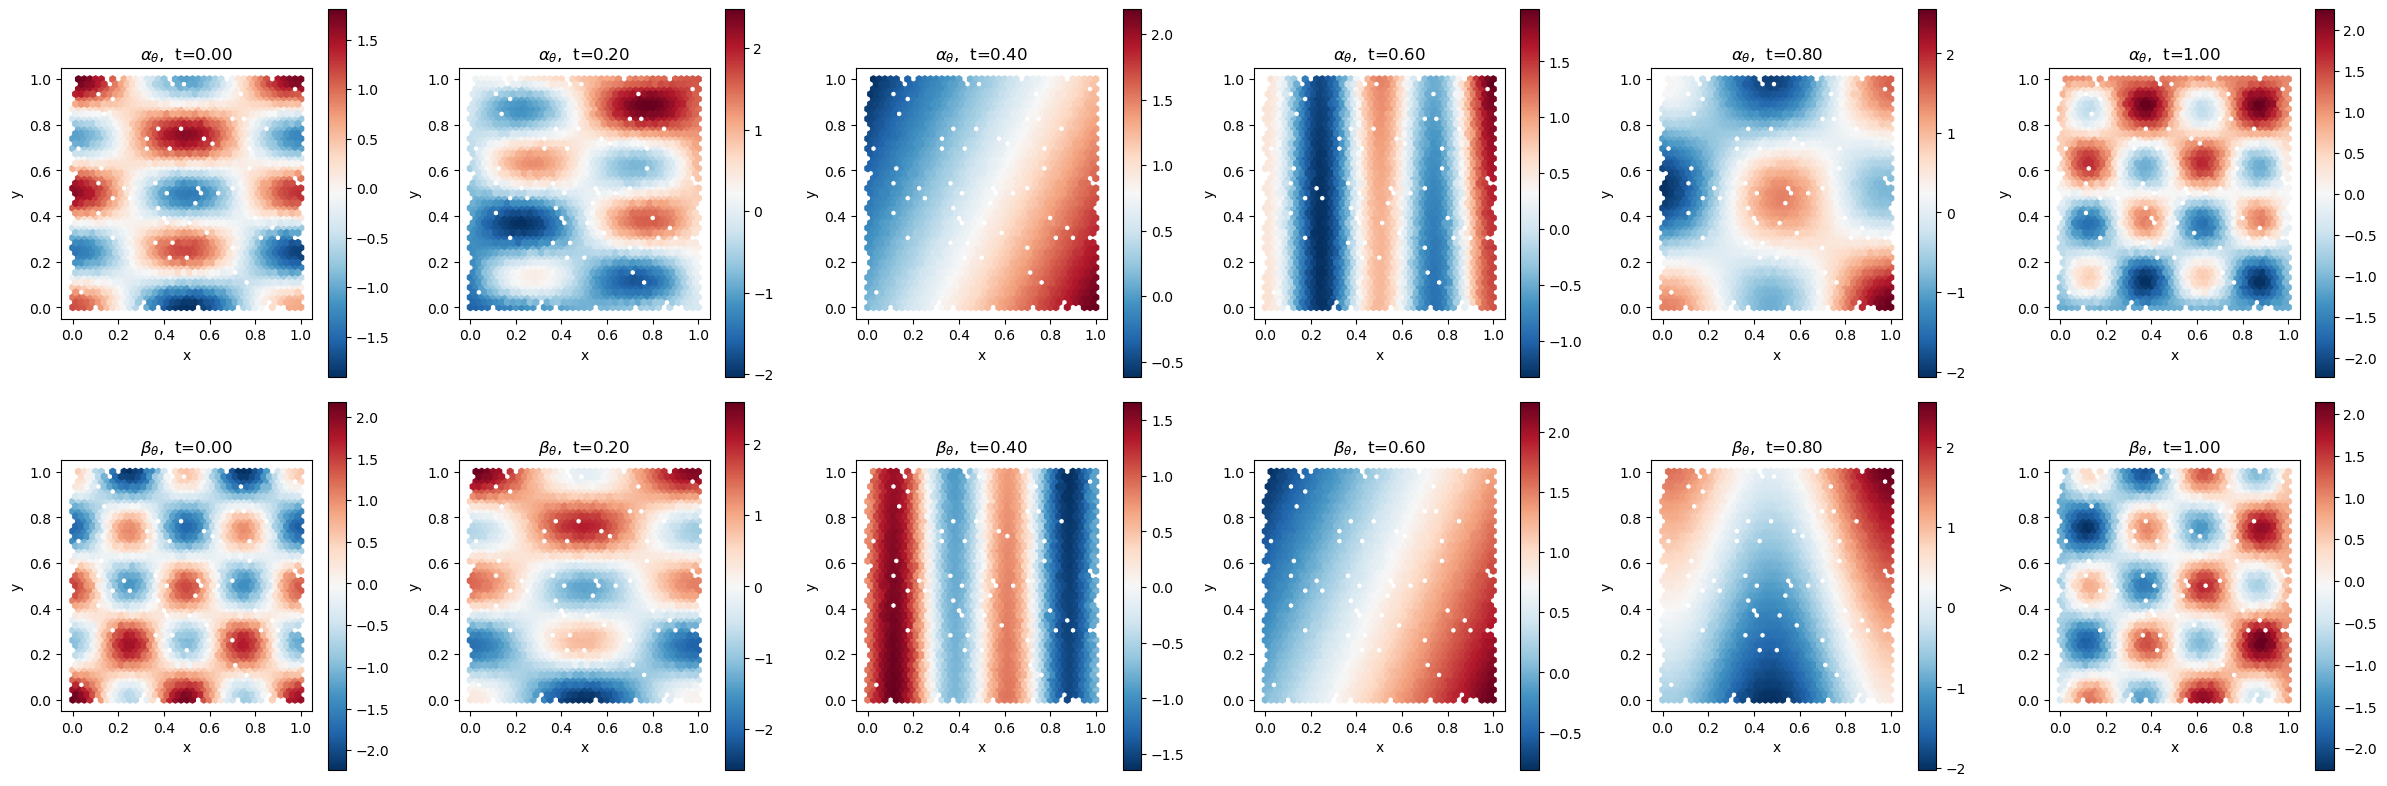

In [7]:
%autoreload 2
import torch
import matplotlib.pyplot as plt
from infidictionary.domain_samplers import SquareSampler

timesteps = torch.linspace(0.0, 1.0, 6)
N_vis = 80
coords_vis = SquareSampler().sample(N_vis).to(device)
N_pts = coords_vis.shape[0]

fig, axes = plt.subplots(nrows=2, ncols=len(timesteps), figsize=(4 * len(timesteps), 8))

with torch.no_grad():
    for j, t_val in enumerate(timesteps):
        t_batch = torch.full((N_pts,), t_val.item(), device=device, dtype=coords_vis.dtype)
        alpha, beta = isometry.function_field(t_batch, coords_vis)  # (N, C)

        for row, (field, name) in enumerate([(alpha, r'$\alpha_\theta$'), (beta, r'$\beta_\theta$')]):
            ax = axes[row, j]
            hb = ax.hexbin(
                coords_vis[:, 0].cpu(),
                coords_vis[:, 1].cpu(),
                C=field[:, 0].cpu(),
                gridsize=40,
                cmap='RdBu_r',
            )
            plt.colorbar(hb, ax=ax)
            ax.set_title(f'{name},  t={t_val:.2f}')
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_aspect('equal')

plt.tight_layout()
plt.show()

The following code verifies the consistency of the pushforward and pullback operators. 

Let $Q_t^s$ denote the transport operator that moves a function from time $t$ to time $s$. This represents:
* A **pushforward** when moving forward in time ($s > t$).
* A **pullback** when moving backward in time ($s < t$).

Because the transformation is an isometry, moving forward and then backward should perfectly reconstruct the original function. Mathematically, the reverse operator $Q_s^t$ is exactly the adjoint (and inverse) of the forward operator $Q_t^s$. 

We can evaluate this consistency by testing if the following identity holds true:

$$Q_s^t Q_t^s f = (Q_t^s)^\ast Q_t^s f = f$$

Run the following which visualizes $f$, $Q_t^s f$, and $Q_s^t Q_t^s f$ and checks whether $f \approx Q_s^t Q_t^s f$:

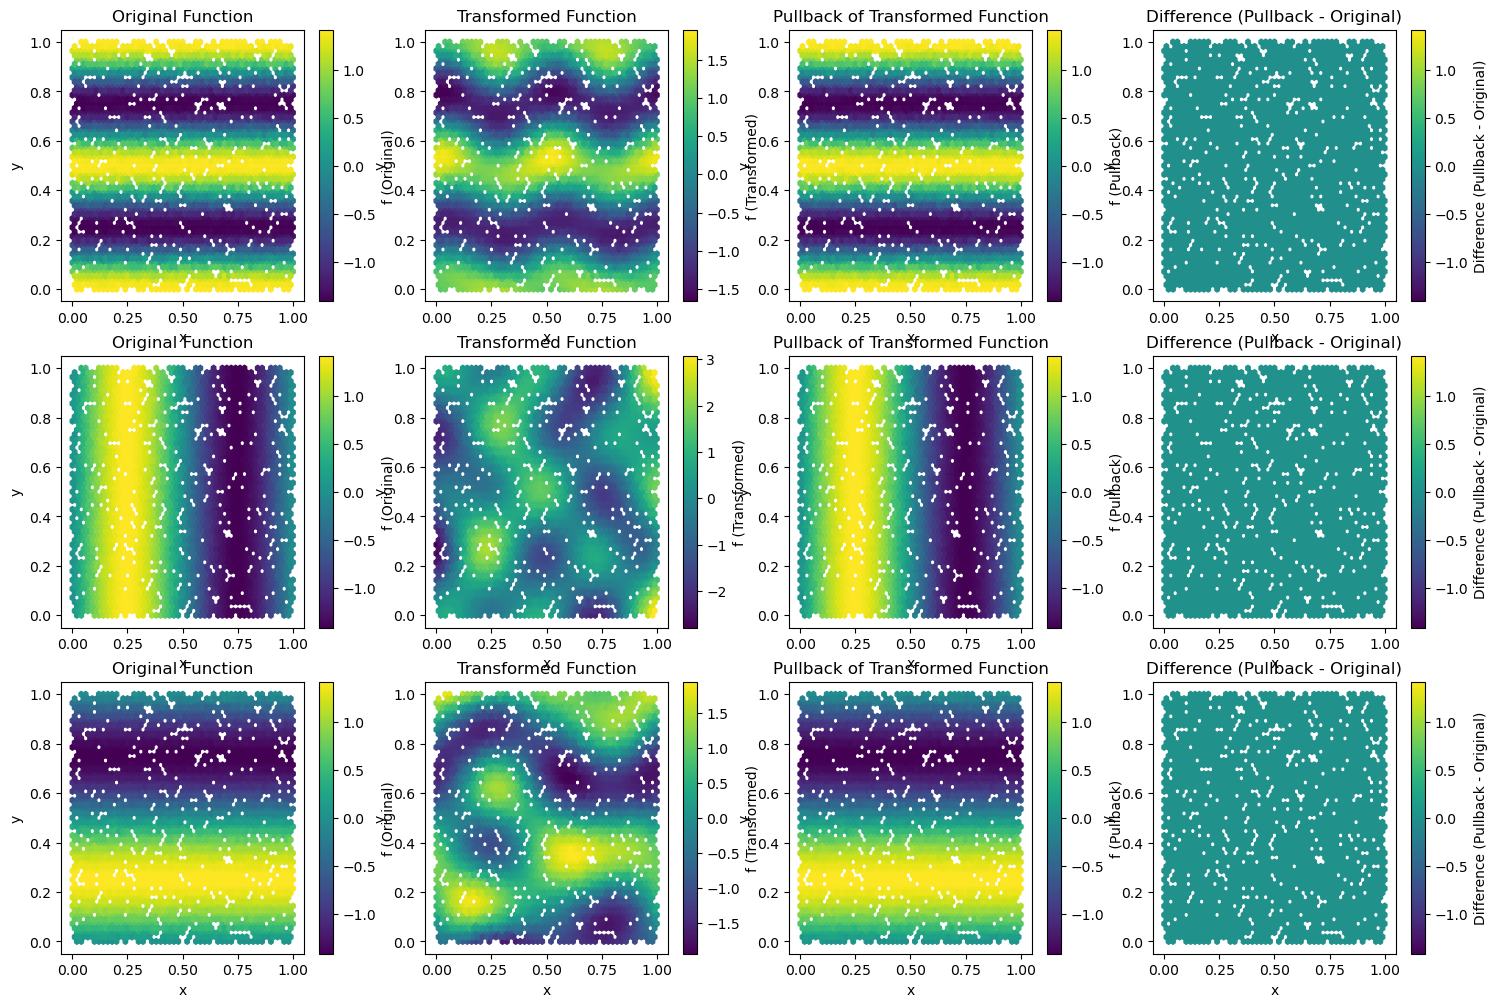

In [8]:
%autoreload 2 
from infidictionary.datasets import RandomBandpassGenerator
from infidictionary.domain_samplers import SquareSampler

start_time = 0.0
end_time = 5.0
N_per_dim = 75
inner_steps = 50

isometry.shuffle_model_state(inner_steps)
coords = SquareSampler().sample(N_per_dim).to(device)
fourier_dictionary = FourierDictionary(
    domain_dim=2,
    num_channels=1,
    p=0.5,
)
f = fourier_dictionary.get_atoms(
    coords, 
    torch.tensor([[0, 2, 0], [-1, 0, 0], [0, -1, 0]]).to(device),
).to(device) # (3, N, 1)

coords, logabsdet, f_transformed = isometry.pushforward(
    coords,
    torch.zeros(coords.shape[0], device=coords.device),
    f,
    start_time=start_time,
    end_time=end_time,
)
coords, logabsdet, f_transformed_pullback = isometry.pullback(
    coords,
    logabsdet,
    f_transformed,
    start_time=start_time,
    end_time=end_time,
)

diff = f_transformed_pullback - f

fig, axes = plt.subplots(nrows=len(f), ncols=4, figsize=(18, 4 * len(f)))

for i in range(len(f)):
    axes[i, 0].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(), 
        C=f[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,0].collections[0], ax=axes[i,0], label='f (Original)') 
    axes[i,0].set_title('Original Function')
    axes[i,0].set_xlabel('x')
    axes[i,0].set_ylabel('y')

    axes[i,1].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(),
        C=f_transformed[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,1].collections[0], ax=axes[i,1], label='f (Transformed)') 
    axes[i,1].set_title('Transformed Function')
    axes[i,1].set_xlabel('x')
    axes[i,1].set_ylabel('y')

    axes[i,2].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(),
        C=f_transformed_pullback[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,2].collections[0], ax=axes[i,2], label='f (Pullback)') 
    axes[i,2].set_title('Pullback of Transformed Function')
    axes[i,2].set_xlabel('x')
    axes[i,2].set_ylabel('y')

    axes[i, 3].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(), 
        C=diff[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    # add the elements in both axes[i, 3] and axes[i,0] to the colorbar so that the colorbar range covers both the original and the difference
    vmin = min(axes[i,0].collections[0].get_array().min(), axes[i,3].collections[0].get_array().min())
    vmax = max(axes[i,0].collections[0].get_array().max(), axes[i,3].collections[0].get_array().max())

    # 2. Update the mappable's limits explicitly
    mappable = axes[i,3].collections[0]
    mappable.set_clim(vmin, vmax)

    # 3. Create the colorbar (it will now use the new limits from the mappable)
    plt.colorbar(mappable, ax=axes[i,3], label='Difference (Pullback - Original)')

    axes[i,3].set_title('Difference (Pullback - Original)')
    axes[i,3].set_xlabel('x')
    axes[i,3].set_ylabel('y')

plt.show()
